In [ ]:
import pandas as pd

df = pd.read_csv('../data/Cars.csv')
df.head() # should print first 5 rows of the dataset

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:
owner_mapping = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}
df['owner'] = df['owner'].map(owner_mapping)
df['owner'].value_counts()#this map the owner column to numerical values and prints the counts of each owner type

owner
1    5289
2    2105
3     555
4     174
5       5
Name: count, dtype: int64

In [ ]:
df['fuel'].value_counts() #the value_counts() function is used to count the occurrences of each unique value in the 'fuel' column of the DataFrame df. It returns a Series containing the counts of unique values, sorted in descending order. This allows you to see how many cars in the dataset use each type of fuel (e.g., Petrol, Diesel, CNG, etc.).

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [ ]:
df = df[df['fuel'].isin(['Diesel', 'Petrol'])]
df['fuel'].value_counts()#filter the dataset to only include rows where the fuel type is either Diesel or Petrol, and then print the counts of each fuel type

fuel
Diesel    4402
Petrol    3631
Name: count, dtype: int64

In [ ]:
df['mileage'].head()#print the first 5 values of the 'mileage' column to see how the mileage data is represented

0     23.4 kmpl
1    21.14 kmpl
2     17.7 kmpl
3     23.0 kmpl
4     16.1 kmpl
Name: mileage, dtype: str

In [ ]:
df['mileage'] = df['mileage'].str.split().str[0].astype(float)
#changes the 'mileage' column from a string to a float by splitting the string and taking the first part, then converting it to a float.

In [ ]:

df['mileage'].dtype #check the data type of the 'mileage' column to confirm that it has been successfully converted to a float

dtype('float64')

In [ ]:
df['engine'].head()#print the first 5 values of the 'engine' column to see how the engine data is represented

0    1248 CC
1    1498 CC
2    1497 CC
3    1396 CC
4    1298 CC
Name: engine, dtype: str

In [ ]:
df = df.dropna()#drop any rows with missing values in the DataFrame df to ensure that the dataset is clean and complete for further analysis or modeling.

In [ ]:
df['engine'] = df['engine'].str.split().str[0].astype(int)
#changes the 'engine' column from a string to int by splitting the string and taking the first part, then converting it to a float.


In [ ]:
df['engine'].dtype#check the data type of the 'engine' column to confirm that it has been successfully converted to an int
df['engine'].head()

0    1248
1    1498
2    1497
3    1396
4    1298
Name: engine, dtype: int64

In [ ]:
df['max_power'].head()#print the first 5 values of the 'max_power' column to see how the max_power data is represented

0        74 bhp
1    103.52 bhp
2        78 bhp
3        90 bhp
4      88.2 bhp
Name: max_power, dtype: str

In [ ]:
df['max_power'] = df['max_power'].str.split().str[0].astype(float)# changes the 'max_power' column from a string to float by splitting the string and taking the first part, then converting it to a float.

In [ ]:
df['max_power'].dtype
df['max_power'].head()#check the data type of the 'max_power' column to confirm that it has been successfully converted to a float and print the first 5 values of the 'max_power' column to see how the max_power data is represented

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64

In [ ]:
df['name'].head()#print the first 5 values of the 'name' column to see how the name data is represented

0          Maruti Swift Dzire VDI
1    Skoda Rapid 1.5 TDI Ambition
2        Honda City 2017-2020 EXi
3       Hyundai i20 Sportz Diesel
4          Maruti Swift VXI BSIII
Name: name, dtype: str

In [ ]:
df['name'] = df['name'].str.split().str[0]# changes the 'name' column to only keep the first word of the car name, which is typically the brand or manufacturer of the car.

In [ ]:
df['name'].head()#print the first 5 values of the 'name' column to see how the name data is represented

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: name, dtype: object

In [ ]:
df =df.rename(columns={'name': 'brand'})# renames the 'name' column to 'brand' in the DataFrame df to better reflect that it contains the brand or manufacturer of the car.

In [ ]:
df.drop(columns=['torque'], inplace=True) #dropping the torque column cause chaky and I don't know what it is. It has a lot of missing values and is not useful for predicting car prices.

In [ ]:
df = df[df['owner'] !=5]

len(df)
#dropped the rows where owner is 5 (Test Drive Car) because it is not useful for predicting car prices. Then printed the length of the dataframe to see how many rows are left.

7814

In [ ]:

df.columns.tolist()#print the list of column names in the DataFrame df to see what features are available for analysis or modeling.


['brand',
 'year',
 'selling_price',
 'km_driven',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage',
 'engine',
 'max_power',
 'seats']

In [ ]:
df.isnull().sum()# check for any remaining missing values in the DataFrame df by summing the number of null values in each column. This helps to identify if there are any columns that still have missing data that may need to be addressed before analysis or modeling.

brand            0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [ ]:
import numpy as np
y = np.log(df['selling_price'])#

In [ ]:
y.head()

0    13.017003
1    12.821258
2    11.970350
3    12.323856
4    11.775290
Name: selling_price, dtype: float64

In [ ]:
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298,88.20,5.0


In [ ]:
df['selling_price'].describe()

count    7.814000e+03
mean     6.515864e+05
std      8.097971e+05
min      2.999900e+04
25%      2.700000e+05
50%      4.550000e+05
75%      6.950000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

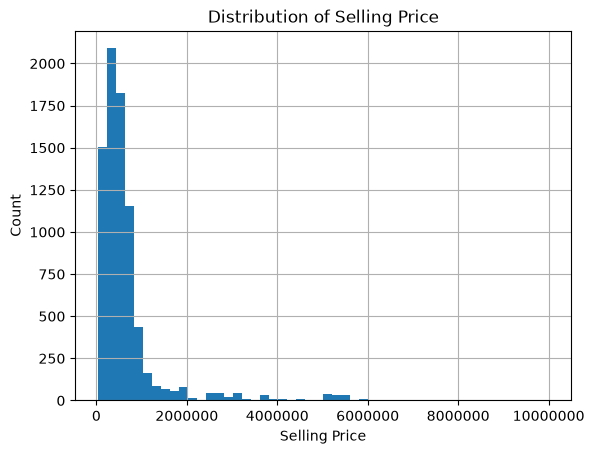

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
df['selling_price'].hist(bins=50)
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.title('Distribution of Selling Price')
plt.show()

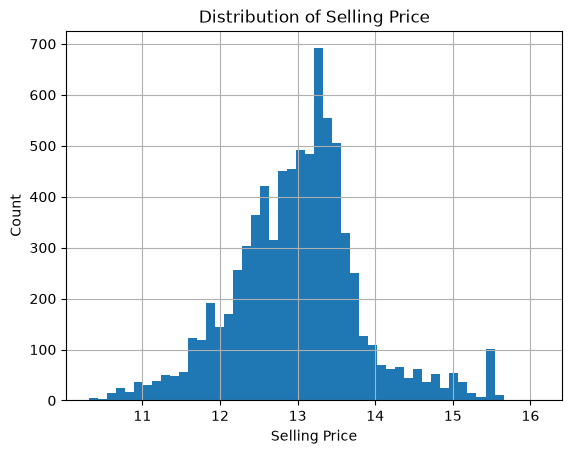

In [ ]:
plt.figure()
y.hist(bins=50)
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.title('Distribution of Selling Price')
plt.show()

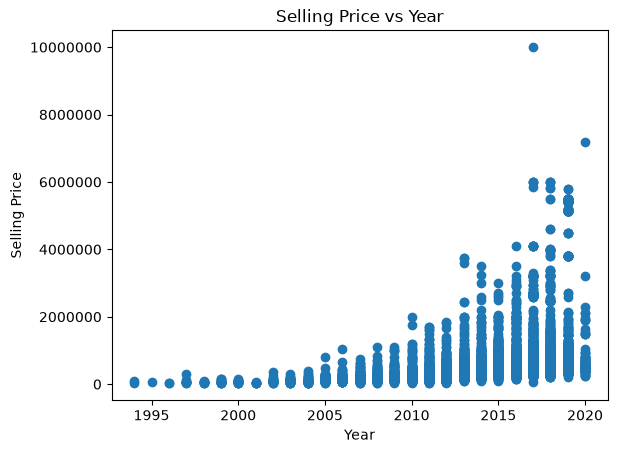

In [ ]:
plt.figure()
plt.scatter(df['year'], df['selling_price'])
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Selling Price vs Year')
plt.show()

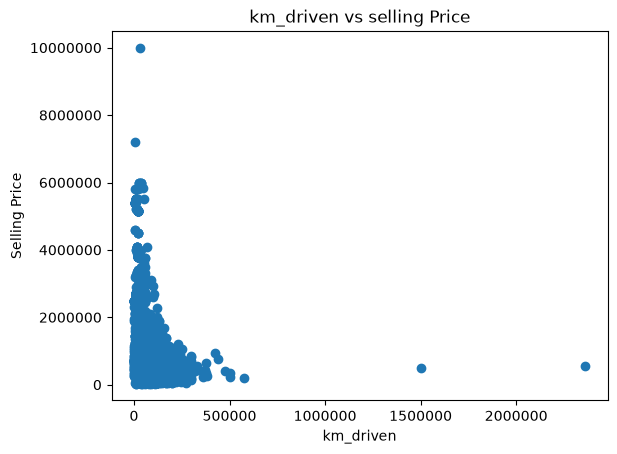

In [ ]:
plt.figure()
plt.scatter(df['km_driven'], df['selling_price'])
plt.ticklabel_format(style='plain', axis='both')
plt.xlabel('km_driven')
plt.ylabel('Selling Price')
plt.title('km_driven vs selling Price')
plt.show()

<Figure size 640x480 with 0 Axes>

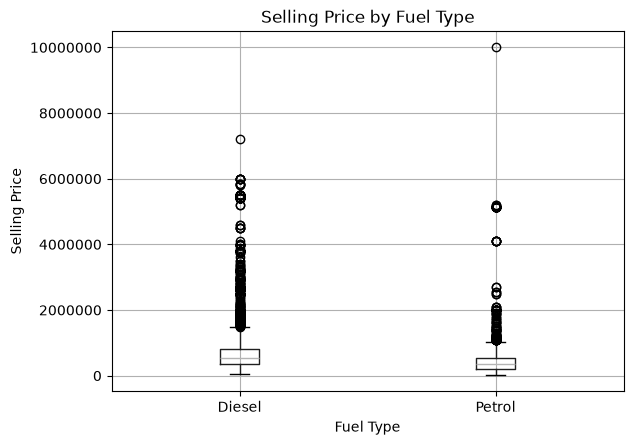

In [ ]:
plt.figure()
df.boxplot(column='selling_price', by='fuel')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.title('Selling Price by Fuel Type')
plt.suptitle('')  
plt.show()

<Figure size 640x480 with 0 Axes>

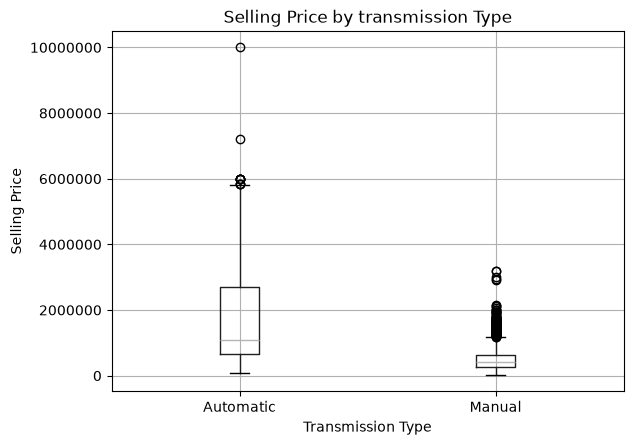

In [ ]:
plt.figure()
df.boxplot(column='selling_price', by='transmission')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.title('Selling Price by transmission Type')
plt.suptitle('')  
plt.show()

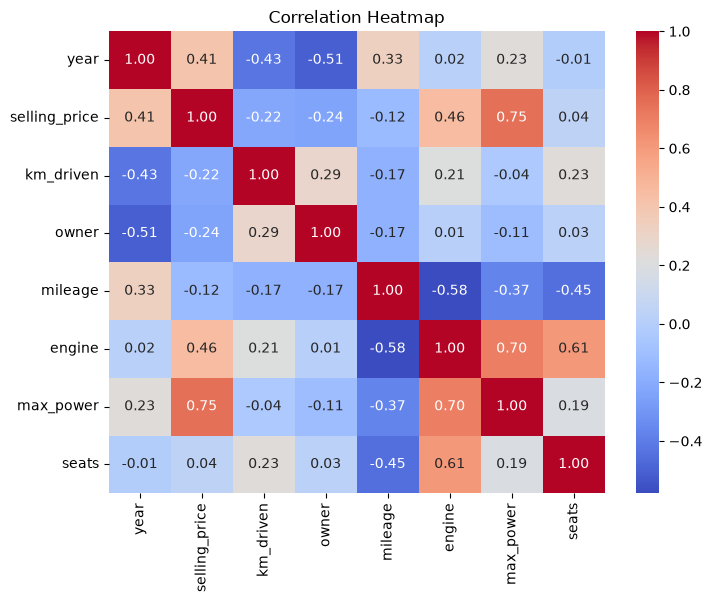

In [ ]:
import seaborn as sns

numeric_cols = ['year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
avg_price_by_brand = df.groupby('brand')['selling_price'].mean().sort_values(ascending=False)

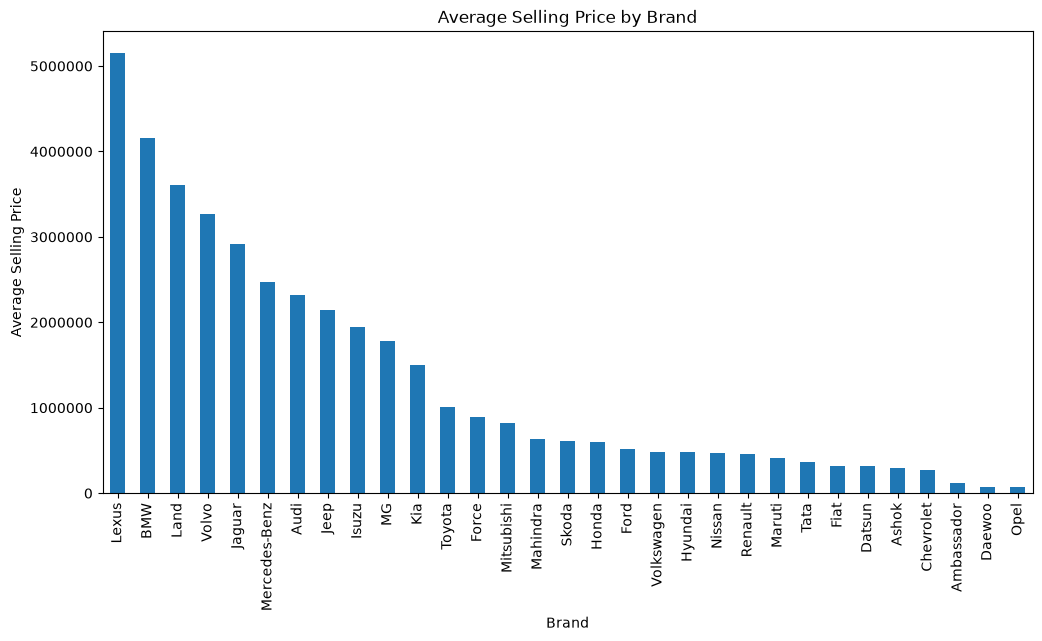

In [ ]:
plt.figure(figsize=(12, 6))
avg_price_by_brand.plot(kind='bar')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Brand')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Brand')
plt.xticks(rotation=90)
plt.show()

In [ ]:
X = pd.get_dummies(df.drop(columns=['selling_price']), columns=['fuel', 'seller_type', 'transmission', 'brand'], drop_first=True)
X.head()
X.shape

(7814, 41)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(6251, 41)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()      # 1. create the model
model.fit(X_train, y_train)     # 2. train it on training data
y_pred = model.predict(X_test)  # 3. use it to predict on unseen test data

In [ ]:
import numpy as np

pred_price = np.exp(y_pred)
actual_price = np.exp(y_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(actual_price, pred_price)
r2 = r2_score(actual_price, pred_price)

print("MSE:", mse)
print("R²:", r2)

MSE: 94369124312.32811
R²: 0.8605473368716712


In [ ]:
rmse = mse ** 0.5
print("RMSE:", rmse)

RMSE: 307195.57990363095


In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor()      
tree_model.fit(X_train, y_train)    
y_pred_tree = tree_model.predict(X_test)

In [ ]:
pred_price_tree = np.exp(y_pred_tree)

mse_tree = mean_squared_error(actual_price, pred_price_tree)
r2_tree = r2_score(actual_price, pred_price_tree)
rmse_tree = mse_tree ** 0.5

print("Decision Tree - MSE:", mse_tree)
print("Decision Tree - R²:", r2_tree)
print("Decision Tree - RMSE:", rmse_tree)

Decision Tree - MSE: 28092976244.056293
Decision Tree - R²: 0.9584859944289773
Decision Tree - RMSE: 167609.59472552963


In [ ]:
y_pred_train_tree = tree_model.predict(X_train)
pred_price_train_tree = np.exp(y_pred_train_tree)
actual_price_train = np.exp(y_train)

r2_train_tree = r2_score(actual_price_train, pred_price_train_tree)
print("Decision Tree - Train R²:", r2_train_tree)

Decision Tree - Train R²: 0.9996014222998271


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_train_rf = rf_model.predict(X_train)

pred_price_rf = np.exp(y_pred_rf)
pred_price_train_rf = np.exp(y_pred_train_rf)

mse_rf = mean_squared_error(actual_price, pred_price_rf)
r2_rf = r2_score(actual_price, pred_price_rf)
rmse_rf = mse_rf ** 0.5

r2_train_rf = r2_score(actual_price_train, pred_price_train_rf)

print("Random Forest - Test R²:", r2_rf)
print("Random Forest - Test RMSE:", rmse_rf)
print("Random Forest - Train R²:", r2_train_rf)

Random Forest - Test R²: 0.9753088393172982
Random Forest - Test RMSE: 129262.4279926734
Random Forest - Train R²: 0.9942901454130075


In [ ]:
import joblib

joblib.dump(rf_model, '../app/model.pkl')
joblib.dump(X_train.columns.tolist(), '../app/columns.pkl')
joblib.dump(X_train.median(), '../app/medians.pkl')

['../app/medians.pkl']

## Summary and Discussion

**Which features are important, and which are not?** The correlation analysis and exploratory plots point to a clear hierarchy of feature importance. `max_power` showed the strongest relationship with `selling_price` (correlation of 0.75), making it the single strongest numeric predictor in the dataset -- more powerful cars command noticeably higher prices. `year` (0.41) and `engine` (0.46) were moderately important, consistent with the intuition that newer cars and cars with bigger engines tend to be pricier, though the `year` vs. `selling_price` scatter plot showed this relationship is non-linear (rapid depreciation in the first few years, flattening out afterward) rather than a straight line. Among categorical features, `transmission` was clearly informative -- Automatic cars sat in a visibly higher price bracket than Manual cars in the box plot comparison -- while `fuel` (Diesel vs. Petrol) showed almost no difference in typical price and is a weak predictor on its own. `brand` also mattered a great deal (luxury brands like Lexus, BMW, and Land Rover averaged 5-10x the price of high-volume brands like Maruti), but with a caveat: brand is a high-cardinality, imbalanced feature, with some brands represented by only a handful of cars, which limits how reliably a model can learn brand-specific pricing patterns. On the weaker end, `mileage` (-0.12), `seats` (0.04), and `km_driven`/`owner` (both around -0.2 to -0.25) showed only weak relationships with price, though `km_driven` did show a clearer non-linear pattern where very high-mileage cars were almost always cheap, even if the relationship wasn't strong across the full range. Finally, `engine` and `max_power` were themselves strongly correlated with each other (0.70), suggesting some redundancy between these two features.

**Which algorithm performed well, and which did not?** Three models were compared on the same train/test split: Linear Regression, a single Decision Tree, and a Random Forest. Linear Regression performed the weakest (test R² = 0.86, RMSE ≈ ₹307,000), which makes sense given the non-linear relationships observed during EDA (e.g., the curved depreciation pattern with `year`, and the wedge-shaped spread with `km_driven`) -- a model that can only fit straight-line relationships between each feature and price is fundamentally limited on data like this. The single Decision Tree performed noticeably better on the test set (R² = 0.958, RMSE ≈ ₹167,600), since trees can naturally capture non-linear, threshold-based patterns (e.g., "if max_power > 100 and year > 2015, price is high"). However, the Decision Tree showed clear signs of overfitting: its training R² was 0.9996, almost a perfect fit, far above its test R² of 0.958. Left with no depth limit, a single tree can grow deep enough to essentially memorize the training data rather than learning a generalizable pattern. The Random Forest resolved this: by training many trees on random subsets of the data and features and averaging their predictions, it achieved both the best test performance (R² = 0.975, RMSE ≈ ₹129,300) and a much smaller train-test gap (train R² = 0.994) than the single tree, indicating better generalization. This matches the general intuition (and what a quick search confirms) that ensemble methods like Random Forest tend to outperform both simple linear models and single trees on tabular data with non-linear relationships, precisely because they combine the flexibility of trees with the variance-reduction of averaging many of them together.

**Overall**, Random Forest was selected as the final model for deployment, given its combination of strong test performance and reasonable generalization. That said, an RMSE of roughly ₹129,000 is still a meaningful absolute error on a dataset with a median price around ₹455,000, and the model would likely benefit from further work: limiting tree depth or tuning other Random Forest hyperparameters to reduce the remaining overfitting gap, addressing the imbalance in the `brand` feature (e.g., grouping rare brands into an "Other" category), and considering whether the `engine`/`max_power` redundancy should be addressed. These are noted as natural next steps beyond the scope of this assignment.